<a href="https://colab.research.google.com/github/Arrah28/AWS-ML-Financial-Health-Analytics-Project/blob/main/Unsupervised_CC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [4]:
cc_df = pd.read_csv('/content/CC GENERAL.csv')
print ('Print Databases loaded successfully')

Print Databases loaded successfully


In [5]:
# --- CREDIT CARD DATASET SUMMARY ---
print("--- CREDIT CARD DATASET OVERVIEW ---")
print(f"Instances (Rows): {cc_df.shape[0]}")
print(f"Features (Columns): {cc_df.shape[1]}")
print("\nMissing Values per Feature:")
print(cc_df.isnull().sum())

--- CREDIT CARD DATASET OVERVIEW ---
Instances (Rows): 8950
Features (Columns): 18

Missing Values per Feature:
CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64


In [6]:
#Mean , Mediam and Standard deviations
print("\n--- CREDIT CARD NUMERICAL MEASURES ---")
stats_cc = cc_df[['BALANCE', 'PURCHASES']].agg(['mean', 'median', 'std'])
print(stats_cc)


--- CREDIT CARD NUMERICAL MEASURES ---
            BALANCE    PURCHASES
mean    1564.474828  1003.204834
median   873.385231   361.280000
std     2081.531879  2136.634782


In [7]:
# --- CATEGORICAL DISTRIBUTION (CREDIT CARD) ---
print("\n--- CREDIT CARD CATEGORICAL DATA ---")
print("Total Unique Customers:", cc_df['CUST_ID'].nunique())


--- CREDIT CARD CATEGORICAL DATA ---
Total Unique Customers: 8950


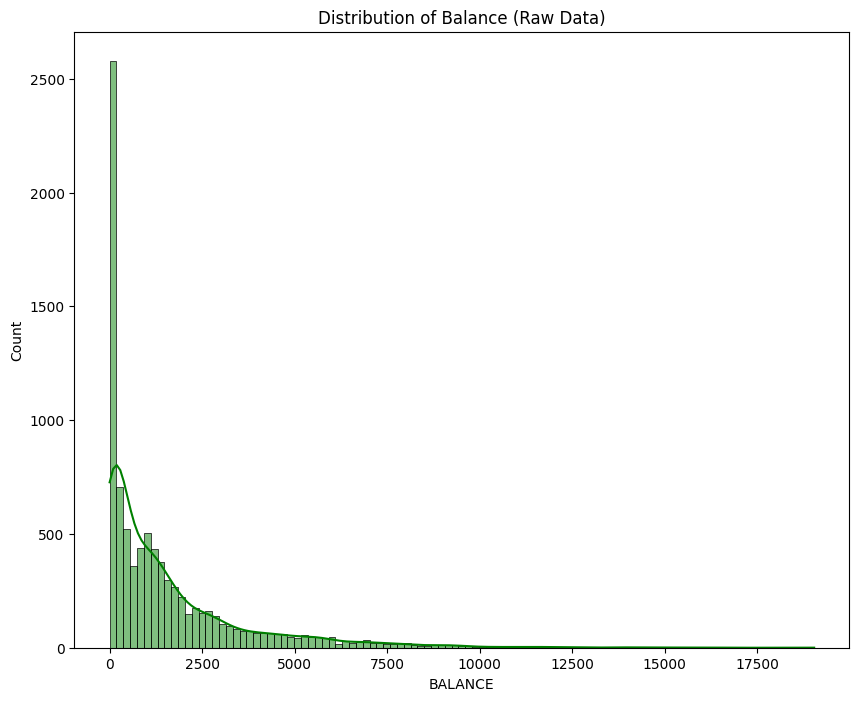

In [8]:
# Histogram used to  Check for "Skewness" in this financial data.
plt.figure(figsize=(10, 8))
sns.histplot(cc_df['BALANCE'], kde=True, color='green')
plt.title('Distribution of Balance (Raw Data)')
plt.show()

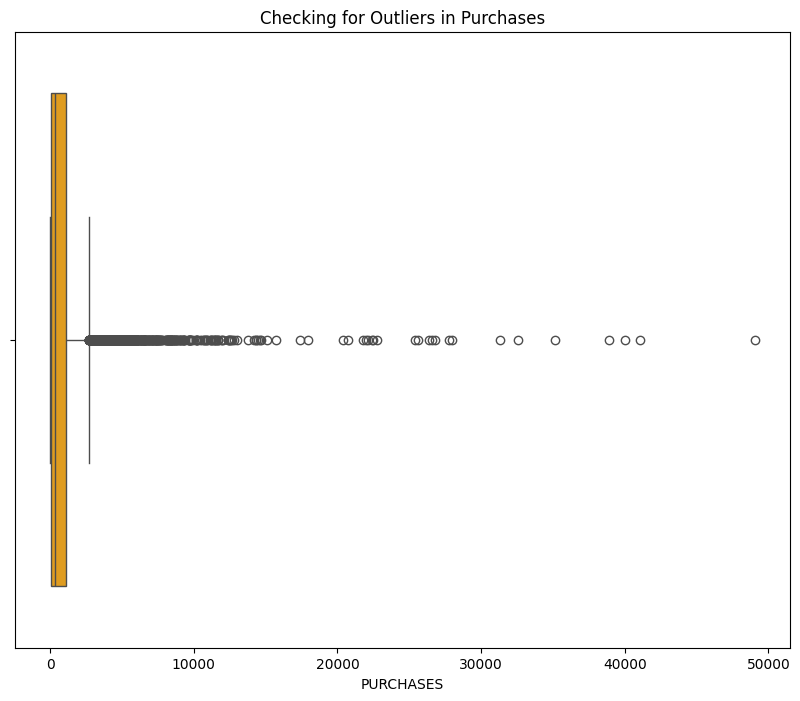

In [9]:
# A boxplot to Check for financial "Outliers" and it will help with the applicaiton explanation of standard scaling later.
plt.figure(figsize=(10, 8))
sns.boxplot(x=cc_df['PURCHASES'], color='orange')
plt.title('Checking for Outliers in Purchases')
plt.show()

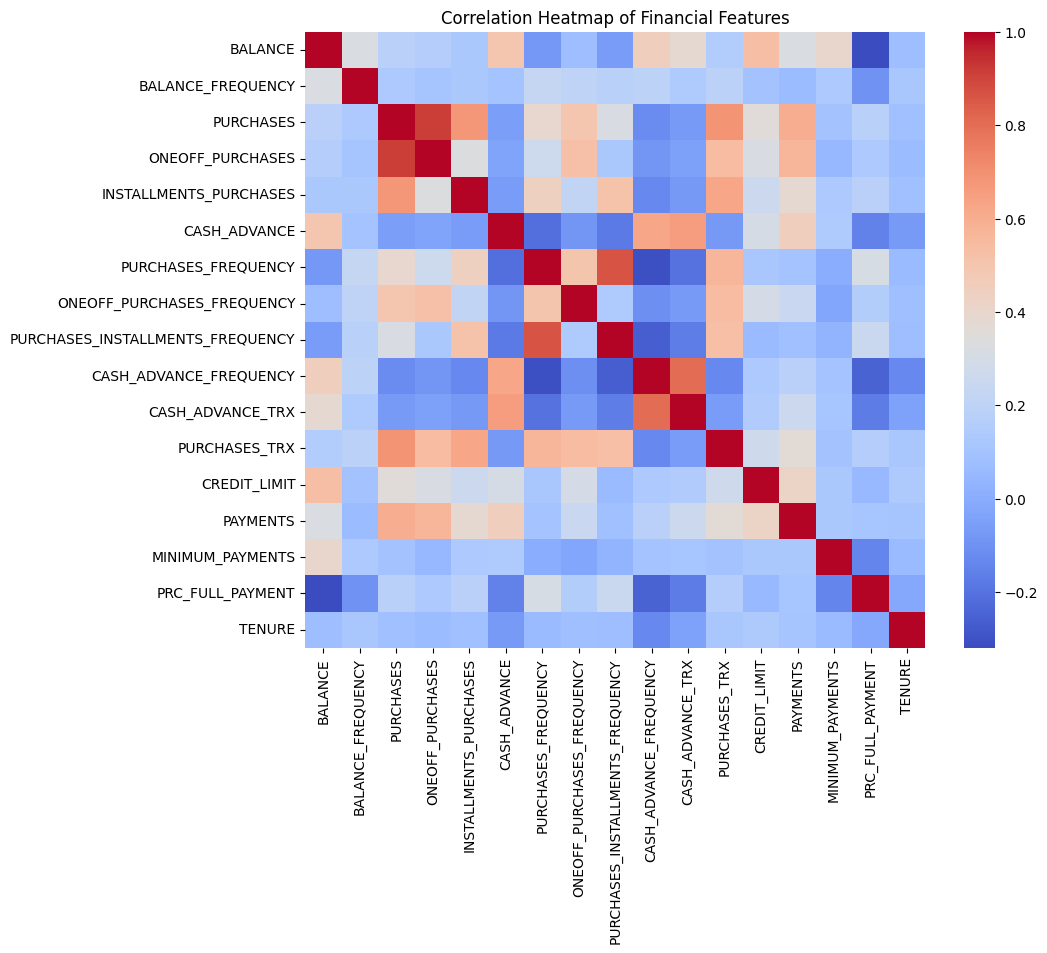

In [10]:
# The Heatmap check for "Correlations", whcih  behaviors are linked before we group them into clusters.
plt.figure(figsize=(10, 8))
sns.heatmap(cc_df.drop('CUST_ID', axis=1).corr(), annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap of Financial Features')
plt.show()

In [11]:
#Data Pre-processing
#this will fill the missing 'MINIMUM_PAYMENTS' and 'CREDIT_LIMIT' with the mean value
imputer = SimpleImputer(strategy='mean')
cc_df['MINIMUM_PAYMENTS'] = imputer.fit_transform(cc_df[['MINIMUM_PAYMENTS']])
cc_df['CREDIT_LIMIT'] = imputer.fit_transform(cc_df[['CREDIT_LIMIT']])

In [12]:
#This will drop the the ID column as its not a behaviour , just extra noise
cc_df_numeric = cc_df.drop('CUST_ID', axis=1)

In [13]:
# Standardise the numerical value so the all hav an average of 0 , making the
# data amore centered and comperable
scaler = StandardScaler()
cc_scaled_array = scaler.fit_transform(cc_df_numeric)

In [14]:
# Convert back to a DataFrame for easier viewing rahter then leaving it as array
cc_final = pd.DataFrame(cc_scaled_array, columns=cc_df_numeric.columns)

In [15]:
print("Credit Card Pre-processing")
cc_final.head()

Credit Card Pre-processing


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.731989,-0.249434,-0.424900,-0.356934,-0.349079,-0.466786,-0.806490,-0.678661,-0.707313,-0.675349,-0.476070,-0.511333,-0.960433,-0.528979,-3.109675e-01,-0.525551,0.36068
1,0.786961,0.134325,-0.469552,-0.356934,-0.454576,2.605605,-1.221758,-0.678661,-0.916995,0.573963,0.110074,-0.591796,0.688639,0.818642,8.931021e-02,0.234227,0.36068
2,0.447135,0.518084,-0.107668,0.108889,-0.454576,-0.466786,1.269843,2.673451,-0.916995,-0.675349,-0.476070,-0.109020,0.826062,-0.383805,-1.016632e-01,-0.525551,0.36068
3,0.049099,-1.016953,0.232058,0.546189,-0.454576,-0.368653,-1.014125,-0.399319,-0.916995,-0.258913,-0.329534,-0.551565,0.826062,-0.598688,4.878305e-17,-0.525551,0.36068
4,-0.358775,0.518084,-0.462063,-0.347294,-0.454576,-0.466786,-1.014125,-0.399319,-0.916995,-0.675349,-0.476070,-0.551565,-0.905464,-0.364368,-2.657913e-01,-0.525551,0.36068
